In [24]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import cumtrapz
from astropy import units as u
from astropy.constants import c
c_in_Mpc_sec = c.to('Mpc/s').value

import os
import sys
sys.path.append('../')
sys.path.append('../src')

from core import InteractionCore_CRPropA_pdis

In [2]:
data_files = {
    'path' : os.path.abspath('/home/leonel/GitProjects/CRPropa3/data-2021-07-30/data/'),
    
    'photodisintegration': {
        'rates_cmb' : 'Photodisintegration/rate_CMB.txt',
        'branchings_cmb' : 'Photodisintegration/branching_CMB.txt',
        'rates_ebl' : 'Photodisintegration/rate_EBL_LopezSaldana21.txt',
        'branchings_ebl' : 'Photodisintegration/branching_EBL_LopezSaldana21.txt',
    },

    'photopionproduction': {
        'rates_cmb' : 'PhotoPionProduction/rate_CMB.txt',
    } 
}

data_files['photodisintegration']['rates_ebl'] = 'Photodisintegration/rate_IRB_Gilmore12.txt'
data_files['photodisintegration']['branchings_ebl'] = 'Photodisintegration/branching_IRB_Gilmore12.txt'

data_files['photodisintegration']['rates_ebl'] = 'Photodisintegration/rate_IRB_Stecker16_upper.txt'
data_files['photodisintegration']['branchings_ebl'] = 'Photodisintegration/branching_IRB_Stecker16_upper.txt'

ic1 = InteractionCore_CRPropA_pdis(data_files)

# Decay rates compared to photomeson rates

In [4]:
from data.nucleardecays import nuclear_data_parser
decaydata = nuclear_data_parser('../data/nubase2016.txt')

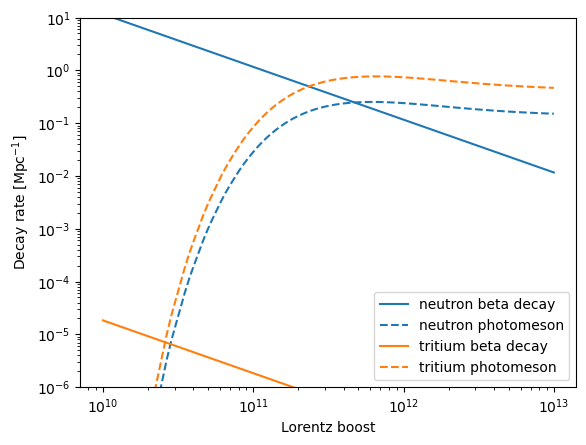

In [35]:
nucdata = decaydata[np.logical_and(decaydata['Z'] == 0, decaydata['A'] == 1)] 
tau = nucdata['half_life'].values / np.log(2) * nucdata['half_life_units'].values

br = np.logspace(10, 13, 100)

pp_rates = np.genfromtxt(os.path.join(data_files['path'], data_files['photopionproduction']['rates_cmb']))
prates = np.interp(br, 10**pp_rates[:, 0], pp_rates[:, 1])
nrates = np.interp(br, 10**pp_rates[:, 0], pp_rates[:, 2])

plt.loglog(br, 1/(br * tau * c_in_Mpc_sec), label='neutron beta decay')
plt.loglog(br, nrates, label='neutron photomeson', c='C0', ls='--')


nucdata = decaydata[np.logical_and(decaydata['Z'] == 1, decaydata['A'] == 3)] 
tau = nucdata['half_life'].values / np.log(2) * nucdata['half_life_units'].values

plt.loglog(br, 1/(br * tau * c_in_Mpc_sec), label='tritium beta decay')
plt.loglog(br, prates + 2*nrates, label='tritium photomeson', c='C1', ls='--')


plt.xlabel('Lorentz boost')
plt.ylabel('Decay rate [Mpc$^{-1}$]')
plt.ylim([1e-6, 10])
plt.legend()